# 06 — Bayesian Inference & Neural Networks — Hands-on Tutorial

In this notebook you will:
- Estimate π using Monte Carlo sampling and watch the estimate converge with sample size
- Contrast the frequentist and Bayesian interpretations of probability
- Fit an astronomical emission line using both approaches — and see when each one wins
- Connect Bayesian thinking to uncertainty quantification in neural networks
- Glimpse simulation-based inference (SBI) — the frontier when likelihoods are intractable

**Prior:** Notebooks 01–05 complete; slides 06 (Bayesian inference)

## Where this fits

| # | Topic | Slide deck | Notebook |
|---|---|---|---|
| 1 | Single neuron | `01_single_neuron.pdf` | `01_single_neuron.ipynb` |
| 2 | Multilayer networks | `02_multilayer_networks.pdf` | `02_training_loop.ipynb` |
| 3 | Backpropagation | `03_backprop_training.pdf` | `03_backpropagation.ipynb` |
| 4 | Optimizers | `07_optimizers.pdf` *(new)* | `04_optimizers.ipynb` |
| 5 | CNNs | `04_cnns.pdf` | `05_cnns.ipynb` |
| 6 | Modern architectures | `05a_attention.pdf` + `05b_practical.pdf` | *(bonus: `bonus_generative_models.ipynb`)* |
| **→ 7** | **Bayesian inference** | **`06_bayesian_inference.pdf`** | **`06_bayesian_inference.ipynb`** |

**Coming from:** Every prior notebook produced point estimates with no uncertainty; here you learn how to put error bars on predictions.

**Leading to:** This is the final structured notebook; the bonus generative-models notebook is after-school exploration.

**If you skipped ahead:** You need to know what a likelihood is and what a probability distribution looks like.


In [1]:
# ── Environment setup ──────────────────────────────────────────────────────────────────────
# Run this cell only on Colab. On JupyterHub, packages are pre-installed.
import sys
if 'google.colab' in sys.modules:
    %pip install -q ipywidgets emcee corner

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import emcee
import corner
from scipy.optimize import curve_fit
from ipywidgets import interact, IntSlider, Dropdown

%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.1 MB/s eta 0:00:00


---

## Part 1 — Monte Carlo and the geometry of probability

Before we talk about Bayesian inference, we need an intuition for *sampling*.

The [Monte Carlo method]{} answers questions about areas, integrals, and probabilities
by drawing random samples and counting outcomes — no calculus required.

**Estimating π:**

A square spanning −1 to 1 in each dimension has area 4.
A circle of radius 1 inscribed inside has area $\pi$.
If you throw darts uniformly at random onto the square,
the fraction that land inside the circle converges to $\pi / 4$:

$$\hat{\pi} = 4 \times \frac{\text{points inside circle}}{\text{total points}}$$

This is not a toy trick. The same idea—draw samples, count or weight outcomes—underlies
Markov Chain Monte Carlo (MCMC), the engine of Bayesian inference.

In [8]:
# ── Part 1: Monte Carlo estimation of π ──────────────────────────────────────────────
# Pre-generate a large pool so the slider gives a smooth, reproducible convergence.
MC_POOL = np.random.RandomState(0).uniform(-1, 1, (1000_000, 2))
MC_INSIDE = (MC_POOL[:, 0]**2 + MC_POOL[:, 1]**2) <= 1.0


def plot_pi_estimate(n_samples=5000):
    n = int(n_samples)
    xy = MC_POOL[:n]
    inside = MC_INSIDE[:n]
    pi_hat = 4 * inside.sum() / n

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left: scatter plot
    ax1.scatter(xy[inside, 0],  xy[inside, 1],  c='steelblue', s=4, alpha=0.5, label='Inside')
    ax1.scatter(xy[~inside, 0], xy[~inside, 1], c='tomato',    s=4, alpha=0.3, label='Outside')
    theta = np.linspace(0, 2 * np.pi, 400)
    ax1.plot(np.cos(theta), np.sin(theta), 'k-', lw=1.5)
    ax1.set_aspect('equal')
    ax1.set_title(f'N = {n:,}  |  \u03c0\u0302 = {pi_hat:.6f}  |  true \u03c0 = {np.pi:.6f}')
    ax1.legend(fontsize=9, markerscale=3)

    # Right: running estimate
    ns = np.arange(1, n + 1)
    running_pi = 4 * np.cumsum(MC_INSIDE[:n]) / ns
    ax2.plot(ns, running_pi, 'steelblue', lw=1.2, label='\u03c0\u0302(N)')
    ax2.axhline(np.pi, color='k', lw=1.5, ls='--', label='True \u03c0')
    se = 4 * np.sqrt((np.pi / 4) * (1 - np.pi / 4) / ns)   # exact MC standard error
    ax2.fill_between(ns,
                     np.pi - se,
                     np.pi + se,
                     alpha=0.2, color='steelblue', label='±1σ band (≈1.642/√N)')
    ax2.set_xlabel('Number of samples')
    ax2.set_ylabel('\u03c0 estimate')
    ax2.set_title('Convergence: estimate narrows as N grows')
    ax2.set_ylim(2.5, 3.8)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f'Error: |\u03c0\u0302 - \u03c0| = {abs(pi_hat - np.pi):.6f}')


interact(
    plot_pi_estimate,
    n_samples=IntSlider(value=500, min=10, max=1000_000, step=1000,
                        description='N samples',
                        style={'description_width': 'initial'}),
);

interactive(children=(IntSlider(value=500, description='N samples', max=1000000, min=10, step=1000, style=Slid…

### Think about it

- At N = 100, the standard error is about 0.16. At N = 10,000, it is about 0.016.
  What is the relationship between N and the expected error? (Look at the shaded band.)
- The shaded region shows ±1σ around the true value, where the Monte Carlo standard error
  is $4\sqrt{p(1-p)/N}$ with $p = \pi/4$ — i.e. $\approx 1.642/\sqrt{N}$. This is the *standard
  error* of the estimate. Why does halving the error require *four times* as many samples?
- If you rerun this experiment with a different random seed, the estimate changes.
  The pool here is fixed (seed = 0) so the slider is smooth. How does fixing the seed
  affect whether you can trust the convergence picture?
- MCMC uses *correlated* samples (each point depends on the previous one).
  Why do correlated samples require more of them to achieve the same effective precision?

---

## Part 2 — Two ways to think about probability

There are two dominant schools of thought on what “probability” means.
Both are mathematically consistent. They differ on what questions they allow you to ask.

| | **Frequentist** | **Bayesian** |
|---|---|---|
| Probability means | Long-run frequency of an event | Degree of belief given current knowledge |
| Parameters are | Fixed but unknown constants | Random variables with distributions |
| What you get | Best-fit values + confidence intervals | Posterior distribution $P(\theta \mid \text{data})$ |
| Prior knowledge | Not encoded formally | Encoded as $P(\theta)$ |
| Question answered | What data are likely if $\theta$ is this? | Given this data, what should I believe about $\theta$? |
| Key tool | MLE, $\chi^2$ fitting, `curve_fit` | Bayes' theorem + MCMC |

**Bayes' theorem:**

$$P(\theta \mid \text{data}) = \frac{P(\text{data} \mid \theta) \; P(\theta)}{P(\text{data})}$$

- $P(\theta \mid \text{data})$ — the **posterior**: what you believe after seeing the data
- $P(\text{data} \mid \theta)$ — the **likelihood**: how probable is the data for a given $\theta$?
- $P(\theta)$ — the **prior**: what you believed before seeing the data
- $P(\text{data})$ — the **evidence**: a normalising constant (usually absorbed into proportionality)

The frequentist maximises the likelihood alone. Under Gaussian noise,
minimising $\chi^2$ *is* maximising the likelihood — this is not a coincidence.

The Bayesian multiplies likelihood by prior and maps the full posterior.

---

## The mathematics of Bayesian inference

### Bayes' theorem

$$\underbrace{P(\theta \mid D)}_{\text{posterior}} \;\propto\; \underbrace{P(D \mid \theta)}_{\text{likelihood}} \; \cdot \; \underbrace{P(\theta)}_{\text{prior}}$$

In log space (numerically stable, and additive):

$$\log P(\theta \mid D) = \log P(D \mid \theta) + \log P(\theta) + \text{const}$$

| Symbol | Meaning |
|--------|---------|
| $\theta$ | Parameters we want to infer — e.g. $(A, \lambda_0)$ for an emission line |
| $D$ | Observed data — the measured flux values |
| $P(\theta)$ | Prior — what we knew before observing $D$ |
| $P(D \mid \theta)$ | Likelihood — how probable the data is if $\theta$ were true |
| $P(\theta \mid D)$ | Posterior — our updated belief after seeing $D$ |

### Gaussian log-likelihood (independent pixel noise)

$$\log P(D \mid \theta) = -\frac{1}{2} \sum_{i=1}^{N} \left(\frac{f_i - \hat{f}_i(\theta)}{\sigma_n}\right)^2 + \text{const}$$

### Gaussian log-prior on line centre

$$\log P(\lambda_0) = -\frac{1}{2}\left(\frac{\lambda_0 - 656.3}{1.0}\right)^2 + \text{const}$$

Maximising the log-posterior is equivalent to minimising $\chi^2$ **plus** a regularisation term from the prior. At high SNR the likelihood dominates and the posterior converges to the MLE.

<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_625/1290051790.py:33: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(lam0_grid, lp,  lw=2,   color='steelblue',  label='Log-prior  $\log P(\lambda_0)$')
/tmp/ipykernel_625/1290051790.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(lam0_grid, ll,  lw=2,   color='darkorange',  label='Log-likelihood  $\log P(D|\lambda_0)$')
/tmp/ipykernel_625/1290051790.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax1.axvline(LAM_TRUE_D, color='gray', ls=':', l

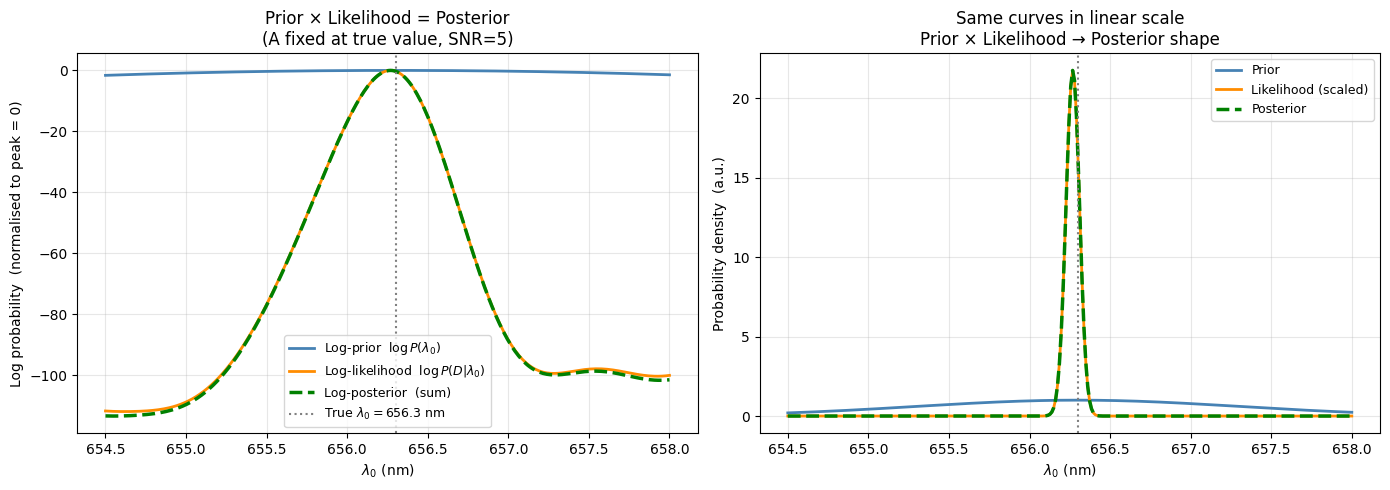

Prior peak at:      656.3 nm  (our calibration knowledge)
Likelihood peak at: 656.27 nm  (best fit to this noisy dataset)
Posterior peak at:  656.27 nm  (compromise)


In [9]:
# ── Plot log-prior, log-likelihood, and log-posterior separately ─────────────

np.random.seed(1)
A_demo       = 0.5        # true amplitude
LAM_TRUE_D   = 656.3      # true line centre (nm)
SIGMA_LINE_D = 0.3        # fixed line width
SNR_DEMO_D   = 5          # moderate SNR

noise_d  = A_demo / SNR_DEMO_D
lam_d    = np.linspace(653.0, 660.0, 60)
flux_obs_d = (1 + A_demo * np.exp(-(lam_d - LAM_TRUE_D)**2 / (2*SIGMA_LINE_D**2))
              + noise_d * np.random.randn(len(lam_d)))

lam0_grid = np.linspace(654.5, 658.0, 300)
A_fixed   = A_demo   # fix A at true value; sweep only lam0 for clarity

def log_prior_1d(lam0):
    return -0.5 * ((lam0 - 656.3) / 1.0) ** 2

def log_likelihood_1d(lam0, A=A_fixed):
    model = 1 + A * np.exp(-(lam_d - lam0)**2 / (2*SIGMA_LINE_D**2))
    return -0.5 * np.sum(((flux_obs_d - model) / noise_d) ** 2)

lp  = np.array([log_prior_1d(l)      for l in lam0_grid])
ll  = np.array([log_likelihood_1d(l) for l in lam0_grid])
lpo = lp + ll

# Normalise each to peak = 0 for comparison
lp  -= lp.max();  ll -= ll.max();  lpo -= lpo.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(lam0_grid, lp,  lw=2,   color='steelblue',  label='Log-prior  $\log P(\lambda_0)$')
ax1.plot(lam0_grid, ll,  lw=2,   color='darkorange',  label='Log-likelihood  $\log P(D|\lambda_0)$')
ax1.plot(lam0_grid, lpo, lw=2.5, color='green', ls='--',
         label='Log-posterior  (sum)')
ax1.axvline(LAM_TRUE_D, color='gray', ls=':', lw=1.5, label=f'True $\lambda_0 = {LAM_TRUE_D}$ nm')
ax1.set_xlabel('$\lambda_0$ (nm)'); ax1.set_ylabel('Log probability  (normalised to peak = 0)')
ax1.set_title(f'Prior × Likelihood = Posterior\n(A fixed at true value, SNR={SNR_DEMO_D})')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Right: exp(log-posterior) = posterior probability density
ax2.plot(lam0_grid, np.exp(lp),  lw=2,   color='steelblue',  label='Prior')
ax2.plot(lam0_grid, np.exp(ll) / np.exp(ll).sum() * np.exp(lp).sum(),
         lw=2, color='darkorange', label='Likelihood (scaled)')
ax2.plot(lam0_grid, np.exp(lpo) / np.exp(lpo).sum() * np.exp(lp).sum(),
         lw=2.5, color='green', ls='--', label='Posterior')
ax2.axvline(LAM_TRUE_D, color='gray', ls=':', lw=1.5)
ax2.set_xlabel('$\lambda_0$ (nm)'); ax2.set_ylabel('Probability density  (a.u.)')
ax2.set_title('Same curves in linear scale\nPrior × Likelihood → Posterior shape')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Prior peak at:      656.3 nm  (our calibration knowledge)')
print(f'Likelihood peak at: {lam0_grid[ll.argmax()]:.2f} nm  (best fit to this noisy dataset)')
print(f'Posterior peak at:  {lam0_grid[lpo.argmax()]:.2f} nm  (compromise)')


### Think about it

- The posterior peak sits between the prior peak and the likelihood peak.   What would happen to the posterior if the SNR were 100 instead of 5?   Which term would dominate?
- The log-prior is a parabola (Gaussian prior = quadratic in log space).   What would a **uniform** prior look like on this plot? How would the posterior change?
- Maximising the log-posterior is equivalent to minimising   $\chi^2 + \lambda(\lambda_0 - 656.3)^2/\sigma_\text{prior}^2$.   Do you recognise this as a form of **regularisation** used in frequentist fitting?
- If the prior were wrong — say, centred at 655.0 nm instead of 656.3 nm —   how much data would you need before the likelihood overwhelms the prior and   the posterior finds the true value?

---

## Part 3 — Fitting a faint emission line: Bayesian wins

**The setup:** A faint Hα emission line sits at $\lambda_0 = 656.3$ nm above a flat continuum.
From atomic physics we know the line centre must be near 656.3 nm
(±1 nm from instrument calibration and Doppler shifts).
The line width is fixed by spectral resolution: $\sigma = 0.3$ nm.

**The model:**

$$\text{flux}(\lambda) = 1 + A \cdot \exp\!\left(-\frac{(\lambda - \lambda_0)^2}{2\sigma^2}\right) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_n^2)$$

We fit for $(A, \lambda_0)$ using `emcee` with:
- **Prior on $A$:** Uniform $(0, 2)$ — we know the line is in emission
- **Prior on $\lambda_0$:** $\mathcal{N}(656.3, 1.0^2)$ — from atomic physics

The cell below pre-computes MCMC chains for four SNR levels. **Run it once** (~30 s);
the widget below is instant.

*Reading the corner plot: the dashed lines mark the 16th, 50th (median), and 84th percentiles — together they bound the central 68% of the posterior, the Bayesian analogue of a ±1σ interval.*

In [10]:
# ── Part 3 setup: pre-compute MCMC chains (run once, ~30 s) ───────────────────────

# True parameters
LAM_TRUE   = 656.3   # nm, Hα
A_TRUE     = 0.5     # emission amplitude (relative to continuum = 1.0)
SIGMA_LINE = 0.3     # nm, line width (fixed — known from instrument resolution)
CONT       = 1.0     # continuum level (fixed)

LAM_GRID = np.linspace(653.0, 660.0, 200)


def emission_model(lam, A, lam0):
    return CONT + A * np.exp(-(lam - lam0)**2 / (2 * SIGMA_LINE**2))


def log_likelihood(theta, lam, flux_obs, noise_sigma):
    A, lam0 = theta
    resid = flux_obs - emission_model(lam, A, lam0)
    return -0.5 * np.sum((resid / noise_sigma)**2)


def log_prior_p3(theta):
    A, lam0 = theta
    if not (0.0 < A < 2.0):
        return -np.inf
    # Gaussian prior on lam0: N(656.3, 1.0^2) from atomic physics
    return -0.5 * ((lam0 - 656.3) / 1.0)**2


def log_posterior_p3(theta, lam, flux_obs, noise_sigma):
    lp = log_prior_p3(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, lam, flux_obs, noise_sigma)


SNR_LEVELS = [2, 5, 10, 50]
CHAINS = {}        # snr -> (raw_chain, flat_samples)
SPECTRA_P3 = {}    # snr -> (lam, flux_obs, noise_level)

rng_p3 = np.random.RandomState(99)

for snr in SNR_LEVELS:
    noise_level = A_TRUE / snr
    flux_obs = (emission_model(LAM_GRID, A_TRUE, LAM_TRUE)
                + noise_level * rng_p3.randn(len(LAM_GRID)))
    SPECTRA_P3[snr] = (LAM_GRID, flux_obs, noise_level)

    ndim, nwalkers = 2, 32
    p0 = np.array([[A_TRUE, LAM_TRUE] + 1e-3 * rng_p3.randn(ndim)
                   for _ in range(nwalkers)])
    p0[:, 0] = np.clip(p0[:, 0], 0.01, None)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, log_posterior_p3,
        args=(LAM_GRID, flux_obs, noise_level)
    )
    sampler.run_mcmc(p0, 2000, progress=False)

    flat = sampler.get_chain(discard=500, thin=10, flat=True)   # (N_samples, 2)
    raw  = sampler.get_chain(discard=500, thin=10)              # (steps, walkers, 2)
    CHAINS[snr] = (raw, flat)
    print(f'SNR={snr:>2d}  done  |  samples={flat.shape[0]}')

print('All chains ready.')

SNR= 2  done  |  samples=4800
SNR= 5  done  |  samples=4800
SNR=10  done  |  samples=4800
SNR=50  done  |  samples=4800
All chains ready.


In [11]:
# ── Part 3: widget — trace plot + corner plot ─────────────────────────────────────────

PARAM_LABELS = ['Amplitude A', 'Centre \u03bb\u2080 (nm)']


def plot_bayes_line(snr=2):
    lam, flux_obs, noise_level = SPECTRA_P3[snr]
    raw, flat = CHAINS[snr]   # raw: (steps, walkers, 2)

    A_med,   lam0_med   = np.median(flat, axis=0)
    A_lo,    A_hi       = np.percentile(flat[:, 0], [16, 84])
    lam0_lo, lam0_hi    = np.percentile(flat[:, 1], [16, 84])

    # ── Figure 1: spectrum + traces + joint posterior ──────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    # Spectrum + posterior median fit
    ax_spec = axes[0, 0]
    ax_spec.errorbar(lam, flux_obs, yerr=noise_level,
                     fmt='o', ms=2, color='steelblue', ecolor='lightblue',
                     alpha=0.6, label='Observed')
    lam_fine = np.linspace(lam.min(), lam.max(), 500)
    ax_spec.plot(lam_fine, emission_model(lam_fine, A_med, lam0_med),
                 'r-', lw=2, label=f'Posterior median\n A={A_med:.2f}, \u03bb\u2080={lam0_med:.2f}')
    ax_spec.axvline(LAM_TRUE, color='k', ls='--', lw=1.2, label=f'True \u03bb\u2080={LAM_TRUE}')
    ax_spec.set_xlabel('Wavelength (nm)')
    ax_spec.set_ylabel('Flux')
    ax_spec.set_title(f'H\u03b1 emission line — SNR = {snr}')
    ax_spec.legend(fontsize=8)

    # Trace: amplitude A
    ax_A = axes[0, 1]
    for i in range(raw.shape[1]):
        ax_A.plot(raw[:, i, 0], alpha=0.3, lw=0.6, color='steelblue')
    ax_A.axhline(A_TRUE, color='k', ls='--', lw=1.5, label=f'True A = {A_TRUE}')
    ax_A.set_ylabel('A (amplitude)')
    ax_A.set_xlabel('MCMC step (post burn-in)')
    ax_A.set_title('Trace: amplitude A')
    ax_A.legend(fontsize=8)

    # Trace: line centre
    ax_lam = axes[1, 1]
    for i in range(raw.shape[1]):
        ax_lam.plot(raw[:, i, 1], alpha=0.3, lw=0.6, color='coral')
    ax_lam.axhline(LAM_TRUE, color='k', ls='--', lw=1.5, label=f'True \u03bb\u2080 = {LAM_TRUE}')
    ax_lam.set_ylabel('\u03bb\u2080 (nm)')
    ax_lam.set_xlabel('MCMC step (post burn-in)')
    ax_lam.set_title('Trace: line centre \u03bb\u2080')
    ax_lam.legend(fontsize=8)

    # Joint posterior 2D histogram
    ax_joint = axes[1, 0]
    ax_joint.hist2d(flat[:, 0], flat[:, 1], bins=40, cmap='Blues')
    ax_joint.scatter([A_TRUE], [LAM_TRUE], c='red', s=100, zorder=5,
                     marker='*', label='True values')
    ax_joint.axvline(A_med,   color='orange', ls='--', lw=1.2)
    ax_joint.axhline(lam0_med, color='orange', ls='--', lw=1.2)
    ax_joint.set_xlabel('A (amplitude)')
    ax_joint.set_ylabel('\u03bb\u2080 (nm)')
    ax_joint.set_title('Joint posterior P(A, \u03bb\u2080 | data)')
    ax_joint.legend(fontsize=8)

    plt.suptitle(
        f'SNR = {snr}  |  '
        f'A = {A_med:.3f} [{A_lo:.3f}, {A_hi:.3f}]  |  '
        f'\u03bb\u2080 = {lam0_med:.3f} [{lam0_lo:.3f}, {lam0_hi:.3f}] nm',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

    # ── Figure 2: corner plot ──────────────────────────────────────────────────
    fig_c = corner.corner(
        flat,
        labels=PARAM_LABELS,
        truths=[A_TRUE, LAM_TRUE],
        truth_color='red',
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt='.3f',
        bins=40,
        color='steelblue',
    )
    fig_c.suptitle(f'Corner plot — SNR = {snr}', y=1.02, fontsize=12)
    plt.show()


interact(
    plot_bayes_line,
    snr=Dropdown(
        options=[
            ('SNR = 2  (very faint — prior matters most)', 2),
            ('SNR = 5  (marginal detection)', 5),
            ('SNR = 10 (clear detection)', 10),
            ('SNR = 50 (bright line — prior irrelevant)', 50),
        ],
        description='SNR level',
        style={'description_width': 'initial'},
    ),
);

interactive(children=(Dropdown(description='SNR level', options=(('SNR = 2  (very faint — prior matters most)'…

### Think about it

- At SNR = 2, the posterior on $\lambda_0$ is wide. Is the true $\lambda_0 = 656.3$ nm still
  within the 68% credible interval shown in the corner plot title? What role is the
  Gaussian prior playing in keeping the chain from wandering far from 656.3 nm?
- Compare the width of the posterior on $A$ at SNR = 2 vs SNR = 50.
  Roughly how many times narrower is it? Does this scaling match $1/\sqrt{\text{SNR}}$?
- Look at the off-diagonal panel of the corner plot at SNR = 2. Is the 2D posterior tilted?
  If so, are $A$ and $\lambda_0$ positively or negatively correlated?
  Physically, why would a line that appears both brighter *and* slightly shifted
  produce a similar observed spectrum?
- The trace plots show 32 walkers evolving simultaneously. At SNR = 2, do the walkers
  overlap and mix well after burn-in, or do some walkers stay stuck in a separate region?
  What does poor mixing tell you about the reliability of the chain?

---

## Part 3b — Watching the posterior narrow

A core intuition of Bayesian inference: the posterior is a **summary of everything you know**, including your prior and all the data seen so far. As you observe more data, the likelihood term dominates and the posterior sharpens around the true value.

The plot below shows how the joint posterior over $(A, \lambda_0)$ evolves as you add spectral bins, holding SNR fixed. Brighter = higher probability density.

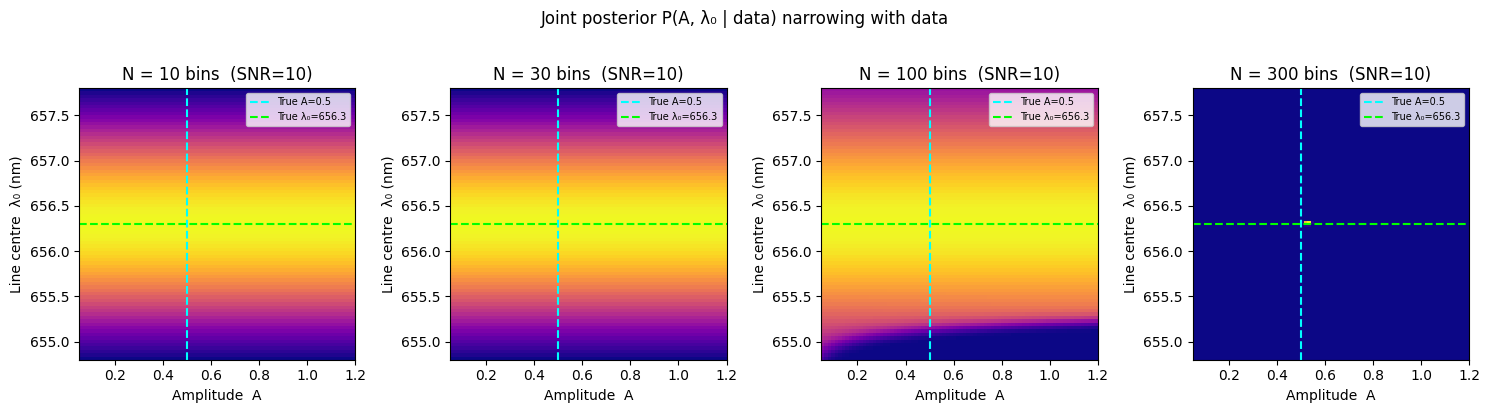

In [12]:
# ── Part 3b: posterior narrowing as data accumulates ─────────────────────────
# Re-use the Part 3 model infrastructure: emission_model, LAM_GRID, etc.

np.random.seed(3)
SNR_DEMO   = 10
NOISE_DEMO = A_TRUE / SNR_DEMO
LAM_DEMO   = np.linspace(653.0, 660.0, 500)
FLUX_DEMO  = (emission_model(LAM_DEMO, A_TRUE, LAM_TRUE)
              + NOISE_DEMO * np.random.randn(len(LAM_DEMO)))

# Parameter grid
A_grid    = np.linspace(0.05, 1.2,  80)
LAM_g     = np.linspace(654.8, 657.8, 80)
AA, LL    = np.meshgrid(A_grid, LAM_g)

N_values  = [10, 30, 100, 300]
fig, axes = plt.subplots(1, len(N_values), figsize=(15, 4))

for ax, N in zip(axes, N_values):
    lam_sub  = LAM_DEMO[:N]
    flux_sub = FLUX_DEMO[:N]
    noise_sub = NOISE_DEMO

    # Log-posterior on the grid
    log_post = np.zeros_like(AA)
    for i in range(AA.shape[0]):
        for j in range(AA.shape[1]):
            A_ij, l_ij = AA[i, j], LL[i, j]
            if A_ij <= 0:
                log_post[i, j] = -np.inf
                continue
            log_prior = -0.5 * ((l_ij - LAM_TRUE) / 1.0) ** 2
            model     = emission_model(lam_sub, A_ij, l_ij)
            log_lik   = -0.5 * np.sum(((flux_sub - model) / noise_sub) ** 2)
            log_post[i, j] = log_prior + log_lik

    # Convert to probability (normalise)
    log_post -= log_post.max()
    post = np.exp(log_post)
    post /= post.sum()

    im = ax.imshow(post, origin='lower', aspect='auto', cmap='plasma',
                   extent=[A_grid[0], A_grid[-1], LAM_g[0], LAM_g[-1]])
    ax.axvline(A_TRUE,   color='cyan',  lw=1.5, ls='--', label=f'True A={A_TRUE}')
    ax.axhline(LAM_TRUE, color='lime',  lw=1.5, ls='--', label=f'True λ₀={LAM_TRUE}')
    ax.set_xlabel('Amplitude  A')
    ax.set_ylabel('Line centre  λ₀ (nm)')
    ax.set_title(f'N = {N} bins  (SNR={SNR_DEMO})')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Joint posterior P(A, λ₀ | data) narrowing with data',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### Think about it

- At N = 10, the posterior is broad and somewhat pear-shaped. Which parameter is   better constrained at low N: the amplitude $A$ or the centre $\lambda_0$? Why?
- At N = 300, compare the posterior width to the prior width (Gaussian, $\sigma = 1$ nm   on $\lambda_0$). Has the data dominated the prior, or is the prior still visible?
- If you observed N = 10 bins but at SNR = 100 instead of SNR = 10, would the   posterior be broader or narrower than the N = 300 case above?   What does this tell you about the relative value of depth vs coverage?
- The posterior is not perfectly Gaussian at N = 10. What makes it asymmetric?

---

## Part 4 — Fitting at high SNR: Frequentist wins

Same model, same Hα line. Now we fix SNR = 50 and vary the number of spectral bins.
The frequentist approach: minimise $\chi^2$ via `scipy.optimize.curve_fit`
(equivalent to maximum likelihood under Gaussian noise).

The Bayesian approach: compute the joint posterior on a fine 2D grid
(no MCMC needed — the high-SNR posterior is nearly Gaussian and well-behaved).

As N grows, three things happen simultaneously:

1. **Cramér–Rao efficiency:** MLE achieves the *minimum possible variance* for any
   unbiased estimator. The error bars shrink as $1/\sqrt{N}$.
2. **Bernstein–von Mises convergence:** The posterior concentrates around the MLE.
   The prior becomes irrelevant — any reasonable prior gives the same answer.
3. **Computational cost:** `curve_fit` runs in milliseconds. MCMC runs in minutes.
   For survey-scale data (SDSS, DESI: tens of millions of spectra), only MLE is practical.

In [13]:
# ── Part 4: MLE vs Bayesian grid posterior as N grows ──────────────────────────────

SNR_P4    = 50
NOISE_P4  = A_TRUE / SNR_P4

# Pre-generate a dense wavelength pool and flux pool for reproducibility
LAM_POOL_P4  = np.linspace(653.0, 660.0, 500)
FLUX_POOL_P4 = (emission_model(LAM_POOL_P4, A_TRUE, LAM_TRUE)
                + NOISE_P4 * np.random.RandomState(7).randn(len(LAM_POOL_P4)))

# Parameter grid for Bayesian posterior
A_GRID    = np.linspace(0.0, 1.5, 120)
LAM_GRID_P4 = np.linspace(655.0, 657.6, 120)
A_2D, LAM_2D = np.meshgrid(A_GRID, LAM_GRID_P4, indexing='ij')


def plot_mle_vs_bayes(n_bins=30):
    n = int(n_bins)
    # Subsample evenly from the pool to span the full wavelength range
    idx = np.round(np.linspace(0, len(LAM_POOL_P4) - 1, n)).astype(int)
    lam_obs  = LAM_POOL_P4[idx]
    flux_obs = FLUX_POOL_P4[idx]

    # ── MLE via curve_fit ──────────────────────────────────────────────────────
    try:
        popt, pcov = curve_fit(
            emission_model, lam_obs, flux_obs,
            p0=[0.4, 656.2],
            sigma=np.full(n, NOISE_P4),
            absolute_sigma=True,
            bounds=([0, 653], [2, 660]),
        )
        A_mle, lam0_mle = popt
        A_err, lam0_err = np.sqrt(np.diag(pcov))
    except RuntimeError:
        A_mle, lam0_mle, A_err, lam0_err = A_TRUE, LAM_TRUE, 0.5, 0.5

    # ── Bayesian grid posterior (vectorised) ────────────────────────────────────
    # model_3d shape: (n_A, n_lam, n_bins)
    model_3d = (CONT
                + A_2D[:, :, np.newaxis]
                * np.exp(-(lam_obs[np.newaxis, np.newaxis, :] - LAM_2D[:, :, np.newaxis])**2
                          / (2 * SIGMA_LINE**2)))
    resid_3d = flux_obs[np.newaxis, np.newaxis, :] - model_3d
    log_like_2d = -0.5 * np.sum((resid_3d / NOISE_P4)**2, axis=2)

    # Gaussian prior on lam0; flat prior on A (hard bounds handled after)
    log_prior_2d = -0.5 * ((LAM_2D - 656.3) / 1.0)**2
    log_prior_2d[A_2D <= 0] = -np.inf

    log_post_2d = log_like_2d + log_prior_2d
    log_post_2d -= np.nanmax(log_post_2d)
    post_2d = np.exp(log_post_2d)
    post_2d = np.where(np.isfinite(post_2d), post_2d, 0.0)
    post_2d /= post_2d.sum()

    # Marginal posteriors
    post_A   = post_2d.sum(axis=1)   # marginal on A
    post_lam = post_2d.sum(axis=0)   # marginal on lam0
    post_A   /= post_A.max()
    post_lam /= post_lam.max()

    # ── Plot ──────────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Spectrum
    lam_fine = np.linspace(653, 660, 400)
    axes[0].errorbar(lam_obs, flux_obs, yerr=NOISE_P4,
                     fmt='o', ms=4, color='steelblue', ecolor='lightblue', alpha=0.7)
    axes[0].plot(lam_fine, emission_model(lam_fine, A_mle, lam0_mle),
                 'r-', lw=2, label=f'MLE  A={A_mle:.3f}, \u03bb\u2080={lam0_mle:.3f}')
    axes[0].axvline(LAM_TRUE, ls='--', color='k', lw=1)
    axes[0].set_xlabel('Wavelength (nm)')
    axes[0].set_ylabel('Flux')
    axes[0].set_title(f'Spectrum: N = {n} bins, SNR = {SNR_P4}')
    axes[0].legend(fontsize=8)

    # Marginal on A
    axes[1].plot(A_GRID, post_A, 'steelblue', lw=2, label='Posterior P(A | data)')
    axes[1].axvline(A_mle,  color='r', lw=2, ls='--', label=f'MLE: {A_mle:.3f}\u00b1{A_err:.3f}')
    axes[1].axvspan(A_mle - A_err, A_mle + A_err, alpha=0.15, color='red')
    axes[1].axvline(A_TRUE, color='k', lw=1.5, ls=':', label=f'True: {A_TRUE}')
    axes[1].set_xlabel('Amplitude A')
    axes[1].set_title('Marginal posterior vs MLE: A')
    axes[1].legend(fontsize=8)

    # Marginal on lam0
    axes[2].plot(LAM_GRID_P4, post_lam, 'coral', lw=2, label='Posterior P(\u03bb\u2080 | data)')
    axes[2].axvline(lam0_mle, color='r', lw=2, ls='--',
                    label=f'MLE: {lam0_mle:.3f}\u00b1{lam0_err:.3f}')
    axes[2].axvspan(lam0_mle - lam0_err, lam0_mle + lam0_err, alpha=0.15, color='red')
    axes[2].axvline(LAM_TRUE, color='k', lw=1.5, ls=':', label=f'True: {LAM_TRUE}')
    axes[2].set_xlabel('Line centre \u03bb\u2080 (nm)')
    axes[2].set_title('Marginal posterior vs MLE: \u03bb\u2080')
    axes[2].legend(fontsize=8)

    plt.suptitle(
        f'N = {n} bins, SNR = {SNR_P4}  |  '
        f'MLE A = {A_mle:.3f} \u00b1 {A_err:.3f}  |  '
        f'Posterior peak A = {A_GRID[np.argmax(post_A)]:.3f}',
        fontsize=10
    )
    plt.tight_layout()
    plt.show()


interact(
    plot_mle_vs_bayes,
    n_bins=IntSlider(value=30, min=10, max=300, step=10,
                     description='N bins',
                     style={'description_width': 'initial'}),
);

interactive(children=(IntSlider(value=30, description='N bins', max=300, min=10, step=10, style=SliderStyle(de…

### Think about it

- At N = 10, does the Bayesian posterior peak at the same value as the MLE?
  If they differ, which is closer to the true value? Why does the Gaussian prior on $\lambda_0$
  pull the posterior peak relative to the MLE at low N?
- At N = 300, how do the posterior width and the MLE confidence interval compare?
  Is the Gaussian prior on $\lambda_0$ still visible as a skew or pull in the posterior?
- The MLE confidence interval is *not* a probability statement about the parameter.
  It means: if we repeated this experiment many times, 68% of such intervals would
  contain the true value. The Bayesian credible interval *is* a probability statement.
  At N = 300, do they give numerically similar bounds?
- DESI measures ~40 million galaxy spectra. At SNR > 10 for most targets, which
  method would you use for a production pipeline, and why?

---

## Part 4b — Frequentist vs Bayesian, side by side

Same emission line, same data — solved **both ways at once**, with sliders for
signal strength (`SNR`) and number of data points (`N`).

- **Frequentist** (`curve_fit`): one best-fit $(A,\lambda_0)$ with a $\pm$ error bar.
- **Bayesian** (grid posterior): median $\pm$ credible interval, using a physics
  prior $\lambda_0 \sim \mathcal{N}(656.3,\,1.0^2)$ (H$\alpha$, barely Doppler-shifted).

Drag `SNR` and `N` **down**: the frequentist error bar on $\lambda_0$ blows up while
the **prior keeps the Bayesian answer anchored**. Turn them **up**: the two answers
become identical — the prior stops mattering.

In [14]:
# -- Part 4b: fit the SAME line frequentist AND Bayesian, with sliders -------
from ipywidgets import FloatSlider

_Ag = np.linspace(-0.4, 1.6, 400)
_Lg = np.linspace(653.0, 659.5, 400)
_AA, _LL = np.meshgrid(_Ag, _Lg, indexing='ij')
PRIOR_MU, PRIOR_SD = 656.3, 1.0            # N(656.3, 1.0^2) prior on lam0

def _median_ci(grid, pmf):
    pmf = pmf / pmf.sum(); cdf = np.cumsum(pmf)
    return (np.interp(0.5, cdf, grid),
            np.interp(0.16, cdf, grid), np.interp(0.84, cdf, grid))

def frequentist_vs_bayesian(SNR=3.0, N=25):
    N = int(N); noise = A_TRUE / SNR
    lam = np.linspace(650.0, 662.0, N)
    rng = np.random.RandomState(int(SNR * 10) + N)
    flux = emission_model(lam, A_TRUE, LAM_TRUE) + noise * rng.randn(N)

    # Frequentist: maximum-likelihood best fit
    try:
        popt, pcov = curve_fit(emission_model, lam, flux, p0=[0.4, 656.0],
                               sigma=np.full(N, noise), absolute_sigma=True,
                               bounds=([-0.5, 653.0], [2.0, 659.5]))
        A_f, L_f = popt; A_fe, L_fe = np.sqrt(np.diag(pcov))
    except RuntimeError:
        A_f = L_f = np.nan; A_fe = L_fe = np.nan

    # Bayesian: grid posterior = likelihood x prior
    logL = np.zeros_like(_AA)
    for k in range(N):
        mu = CONT + _AA * np.exp(-(lam[k] - _LL)**2 / (2 * SIGMA_LINE**2))
        logL += -0.5 * ((flux[k] - mu) / noise)**2
    logpost = logL - 0.5 * ((_LL - PRIOR_MU) / PRIOR_SD)**2
    post = np.exp(logpost - logpost.max())
    A_b, A_blo, A_bhi = _median_ci(_Ag, post.sum(1))
    L_b, L_blo, L_bhi = _median_ci(_Lg, post.sum(0))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2),
                           gridspec_kw={'width_ratios': [2, 1]})
    lam_fine = np.linspace(650, 662, 400)
    ax[0].plot(lam, flux, 'o', ms=4, color='0.5', alpha=0.7, label='data')
    ax[0].plot(lam_fine, emission_model(lam_fine, A_f, L_f), 'C3', lw=2,
               label='frequentist best-fit')
    ax[0].plot(lam_fine, emission_model(lam_fine, A_b, L_b), 'C0', lw=2, ls='--',
               label='Bayesian posterior median')
    ax[0].axvline(LAM_TRUE, color='k', ls=':', alpha=0.6, label='truth')
    ax[0].set_xlabel('wavelength (nm)'); ax[0].set_ylabel('flux')
    ax[0].set_title(f'SNR = {SNR:.0f},  N = {N}'); ax[0].legend(fontsize=8)

    ax[1].errorbar([0], [L_f], yerr=[L_fe], fmt='o', color='C3', capsize=6,
                   label='frequentist')
    ax[1].errorbar([1], [L_b], yerr=[[L_b - L_blo], [L_bhi - L_b]], fmt='s',
                   color='C0', capsize=6, label='Bayesian')
    ax[1].axhline(LAM_TRUE, color='k', ls=':', alpha=0.6)
    ax[1].fill_between([-0.5, 1.5], PRIOR_MU - PRIOR_SD, PRIOR_MU + PRIOR_SD,
                       color='C0', alpha=0.08)
    ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(['Freq.', 'Bayes'])
    ax[1].set_xlim(-0.5, 1.5); ax[1].set_ylabel(r'$\lambda_0$ (nm)')
    ax[1].set_title(r'$\lambda_0$ estimate $\pm$ error'); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print(f"truth:        A = {A_TRUE:.2f},  lam0 = {LAM_TRUE:.2f} nm")
    print(f"Frequentist:  A = {A_f:.2f} +/- {A_fe:.2f},   lam0 = {L_f:.2f} +/- {L_fe:.2f} nm")
    print(f"Bayesian:     A = {A_b:.2f} (+{A_bhi-A_b:.2f}/-{A_b-A_blo:.2f}),   "
          f"lam0 = {L_b:.2f} (+{L_bhi-L_b:.2f}/-{L_b-L_blo:.2f}) nm")

interact(frequentist_vs_bayesian,
         SNR=FloatSlider(value=3.0, min=1.0, max=30.0, step=1.0, description='SNR'),
         N=IntSlider(value=25, min=15, max=120, step=5, description='N points'));

interactive(children=(FloatSlider(value=3.0, description='SNR', max=30.0, min=1.0, step=1.0), IntSlider(value=…

### Think about it

- At **SNR = 1, N = 15**, how far is the frequentist $\lambda_0$ from the truth, and
  how big is its error bar? Where does the Bayesian estimate sit — and *why* is it
  closer? (Look at the shaded prior band on the right panel.)
- Push **SNR = 30, N = 120**. Do the estimates still differ? What happened to the prior's influence?
- The Bayesian amplitude $A$ is often pulled *low* at low SNR. The prior is only on
  $\lambda_0$ — so why does constraining the centre also move $A$? (Hint: correlation.)
- Set `PRIOR_SD = 5.0` (a weak prior). At low SNR, does Bayesian now look more
  frequentist? That knob is the dial between the two philosophies.

---

## Part 5 — Neural networks as Bayesian machines

A trained neural network produces a **point estimate** — a single output per input.
It does not tell you how *confident* it is.

The weights are learned from finite data. Like any model parameter fit to data,
there is uncertainty in those weights.
A **Bayesian neural network (BNN)** maintains a distribution over weights:

$$P(w \mid \text{data}) \propto P(\text{data} \mid w) \; P(w)$$

**Gal & Ghahramani (2016)** showed that a network trained with dropout
and evaluated with dropout *active at test time*
approximates Bayesian inference over the weight posterior.

> Running the same input through a dropout network N times
> produces N different predictions. Their **spread** is a proxy for epistemic uncertainty.

This is **MC Dropout** — zero implementation cost if dropout is already in the network.
Just leave dropout **on** at test time.

Below: a simple MLP trained to classify synthetic pulsar-like data.
Two input features: period stability and DM excess.
The training cell runs once (~10 s); the widget is instant.

In [ ]:
# ── Part 5 setup: train a simple MLP with dropout (run once, ~10 s) ───────────────

rng_p5 = np.random.RandomState(42)

# Pulsars: high period stability, elevated DM
n_pulsars = 200
pulsars_X = rng_p5.randn(n_pulsars, 2) * [0.4, 0.5] + [1.5, 1.8]

# RFI / noise candidates: spread around origin
n_rfi = 400
rfi_X = rng_p5.randn(n_rfi, 2) * [0.8, 0.7]

X_all = np.vstack([pulsars_X, rfi_X]).astype(np.float32)
y_all = np.concatenate([np.ones(n_pulsars), np.zeros(n_rfi)]).astype(np.float32)

shuffle_idx = rng_p5.permutation(len(y_all))
X_all, y_all = X_all[shuffle_idx], y_all[shuffle_idx]

X_t = torch.tensor(X_all)
y_t = torch.tensor(y_all).unsqueeze(1)


class PulsarMLP(nn.Module):
    def __init__(self, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.ReLU(), nn.Dropout(p=p_drop),
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(p=p_drop),
            nn.Linear(64, 1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


model_p5 = PulsarMLP(p_drop=0.3)
optimizer = optim.Adam(model_p5.parameters(), lr=1e-3)
criterion = nn.BCELoss()

for epoch in range(400):
    model_p5.train()
    optimizer.zero_grad()
    loss = criterion(model_p5(X_t), y_t)
    loss.backward()
    optimizer.step()

print(f'Training complete. Final loss: {loss.item():.4f}')

# Grid for decision surface visualisation
xx, yy = np.meshgrid(np.linspace(-3.0, 4.0, 80), np.linspace(-3.0, 4.5, 80))
GRID_T = torch.tensor(
    np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)
)

In [ ]:
# ── Part 5: MC Dropout uncertainty widget ──────────────────────────────────────────

def plot_mc_dropout(mode='MC Dropout (30 passes)', n_passes=30):
    with torch.no_grad():
        if mode == 'Single pass (eval mode)':
            model_p5.eval()
            preds = model_p5(GRID_T).numpy().reshape(xx.shape)
            uncertainty = np.zeros_like(preds)
        else:
            model_p5.train()   # keep dropout active
            all_preds = np.stack(
                [model_p5(GRID_T).numpy().reshape(xx.shape)
                 for _ in range(int(n_passes))],
                axis=0
            )
            preds = all_preds.mean(axis=0)
            uncertainty = all_preds.std(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Decision surface
    im0 = axes[0].contourf(xx, yy, preds, levels=50, cmap='RdBu_r', vmin=0, vmax=1)
    axes[0].contour(xx, yy, preds, levels=[0.5], colors='k', linewidths=2)
    axes[0].scatter(pulsars_X[:, 0], pulsars_X[:, 1],
                    c='steelblue', s=15, alpha=0.7, label='Pulsar')
    axes[0].scatter(rfi_X[:, 0], rfi_X[:, 1],
                    c='tomato', s=15, alpha=0.5, label='RFI')
    plt.colorbar(im0, ax=axes[0], label='P(pulsar)')
    axes[0].set_xlabel('Period stability')
    axes[0].set_ylabel('DM excess')
    axes[0].set_title('Predicted P(pulsar) — decision surface')
    axes[0].legend(fontsize=9)

    # Uncertainty
    if mode == 'Single pass (eval mode)':
        axes[1].text(0.5, 0.5,
                     'No uncertainty estimate\nin single-pass eval mode.',
                     ha='center', va='center', fontsize=14,
                     transform=axes[1].transAxes)
        axes[1].axis('off')
    else:
        im1 = axes[1].contourf(xx, yy, uncertainty, levels=50, cmap='hot_r')
        axes[1].contour(xx, yy, preds, levels=[0.5],
                        colors='white', linewidths=2, linestyles='--')
        axes[1].scatter(pulsars_X[:, 0], pulsars_X[:, 1], c='steelblue', s=15, alpha=0.7)
        axes[1].scatter(rfi_X[:, 0], rfi_X[:, 1], c='tomato', s=15, alpha=0.5)
        plt.colorbar(im1, ax=axes[1], label='Predictive std dev (uncertainty)')
        axes[1].set_xlabel('Period stability')
        axes[1].set_ylabel('DM excess')
        axes[1].set_title(f'MC Dropout uncertainty ({n_passes} passes)')

    plt.suptitle(
        'MC Dropout: same model, same weights — only the dropout mask changes each pass',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


interact(
    plot_mc_dropout,
    mode=Dropdown(
        options=['Single pass (eval mode)', 'MC Dropout (30 passes)'],
        description='Mode',
        style={'description_width': 'initial'},
    ),
    n_passes=IntSlider(value=30, min=5, max=100, step=5,
                       description='# passes',
                       style={'description_width': 'initial'}),
);

### Think about it

- In MC Dropout mode, where is the uncertainty highest — near the decision boundary
  or far from the training data? Is this what you would expect from an uncertainty measure?
- In the region where pulsars and RFI overlap (period stability ≈ 0.5, DM ≈ 0.5),
  does the model's uncertainty increase? Is this uncertainty *epistemic* (could be
  reduced with more data) or *aleatoric* (irreducible noise in the problem)?
- Compare n_passes = 5 vs n_passes = 100. How much does the uncertainty map change?
  At roughly what number of passes does the estimate appear stable?
- MC Dropout is an *approximation* to Bayesian inference — not exact.
  Gal & Ghahramani showed it corresponds to approximate variational inference.
  In what region of feature space might MC Dropout give a misleadingly *low*
  uncertainty even when the model should be uncertain?

---

## Looking ahead — Simulation-Based Inference

<div style="background: #e8f4f8; border-left: 4px solid #2196F3; padding: 1.2em 1.4em; margin: 1em 0; border-radius: 4px;">
<strong>When is the likelihood intractable?</strong>
<ul>
<li><strong>Gravitational wave parameter estimation:</strong> the signal model is a full
  waveform simulation; the likelihood has no closed form.</li>
<li><strong>Cosmological parameter inference:</strong> connecting Ω<sub>m</sub> and σ<sub>8</sub>
  to observed galaxy clustering requires running an N-body simulation.</li>
<li><strong>Stellar population synthesis:</strong> the likelihood of an observed SED requires
  marginalising over millions of unresolved stellar evolutionary tracks.</li>
</ul>
</div>

**Simulation-Based Inference (SBI)** sidesteps this by training a neural network
to learn the posterior directly from simulated data:

$$\bigl(\theta_{\text{sim}},\; x_{\text{sim}}\bigr) \xrightarrow{\text{neural posterior estimator}} \hat{P}(\theta \mid x_{\text{obs}})$$

Simulate millions of (parameter, observation) pairs.
Train a normalising flow or mixture density network to approximate the posterior.
Evaluate on real observations — no likelihood function required.

This is Bayesian inference **without writing a single likelihood function**.

*Reference: Cranmer, Brehmer & Louppe (2020) — The frontier of simulation-based inference.
PNAS 117(48). arXiv:1911.01429*

*Software: the `sbi` package implements multiple SBI algorithms
(SNPE, SNLE, SNRE) with a clean Python API.*

---

## Exercise — Implement `log_posterior`

The core function that every MCMC sampler evaluates is the log-posterior.
It combines the log-prior (what you knew before) with the log-likelihood
(how probable the data are under the model).

For the two-parameter Gaussian emission line model:

$$\log P(\theta \mid \text{data})
  = \underbrace{-\frac{1}{2}\left(\frac{\lambda_0 - 656.3}{1.0}\right)^2}_{\log P(\lambda_0)}
    + \underbrace{-\frac{1}{2} \sum_i \left(\frac{f_i - \hat{f}_i}{\sigma_n}\right)^2}_{\log P(\text{data} \mid \theta)}$$

with a flat prior on $A$ that returns $-\infty$ outside $(0, 2)$.

Implement the function below, then run the test cell.

In [ ]:
def log_posterior_exercise(theta, lam, flux_obs, noise_sigma):
    """
    Log-posterior for the two-parameter Gaussian emission line model.

    Parameters
    ----------
    theta       : (A, lam0) -- amplitude and line centre in nm
    lam         : np.ndarray -- wavelength grid (nm)
    flux_obs    : np.ndarray -- observed flux values
    noise_sigma : float -- per-pixel noise standard deviation

    Returns
    -------
    float -- log P(theta | data) = log_prior + log_likelihood
             Return -np.inf if any parameter is outside its prior support.

    Model:  flux_model = 1.0 + A * exp(-(lam - lam0)**2 / (2 * 0.3**2))
    Prior:  A   ~ Uniform(0, 2)
            lam0 ~ Normal(656.3, 1.0**2)
    """
    A, lam0 = theta

    # Step 1: compute log_prior
    #   - if A <= 0 or A >= 2: return -np.inf  (outside prior support)
    #   - log_prior_lam0 = -0.5 * ((lam0 - 656.3) / 1.0)**2

    # Step 2: compute log_likelihood
    #   - flux_model = emission_model(lam, A, lam0)
    #   - log_like = -0.5 * np.sum(((flux_obs - flux_model) / noise_sigma)**2)

    # Step 3: return log_prior + log_likelihood

    raise NotImplementedError('Fill in log_posterior_exercise')

In [ ]:
# ── Test: compare to the reference implementation used in Part 3 ───────────────────

lam_test, flux_test, noise_test = SPECTRA_P3[10]
theta_true = np.array([A_TRUE, LAM_TRUE])

your_val = log_posterior_exercise(theta_true, lam_test, flux_test, noise_test)
ref_val  = log_posterior_p3(theta_true, lam_test, flux_test, noise_test)

print(f'Your log_posterior at true params : {your_val:.4f}')
print(f'Reference log_posterior           : {ref_val:.4f}')
assert np.isclose(your_val, ref_val, atol=1e-6), \
    f'Values do not match: yours={your_val:.4f}, reference={ref_val:.4f}'

# At clearly wrong params, log_posterior should be much lower
theta_bad = np.array([2.0, 650.0])
your_bad  = log_posterior_exercise(theta_bad, lam_test, flux_test, noise_test)
assert your_bad < your_val - 50, \
    'log_posterior at wrong params should be much lower than at true params.'

# Boundary: A = 0 must return -inf
theta_boundary = np.array([0.0, LAM_TRUE])
assert log_posterior_exercise(theta_boundary, lam_test, flux_test, noise_test) == -np.inf, \
    'A = 0 should return -np.inf (outside prior support).'

print('\u2713 Correct.')

---

## Going further

### Part A — Go deeper

We fitted two free parameters $(A, \lambda_0)$ with the line width $\sigma$ fixed.
In practice, the spectral resolution is not perfectly known, and $\sigma$ encodes
physical information about thermal and turbulent broadening.

**Challenge:** Extend the MCMC fit to three free parameters $(A, \lambda_0, \sigma_{\text{line}})$.
Add a physically motivated prior on $\sigma$: a half-Normal with scale 0.5 nm
(widths beyond ~1 nm are strongly penalised). Re-run `emcee` and examine the 3-parameter
corner plot. Does freeing $\sigma$ increase the uncertainty on $\lambda_0$?

*Suggested approach:* Update `log_prior_p3` to include
`-0.5 * (sigma / 0.5)**2` for `sigma > 0` and `-np.inf` otherwise.
Update `emission_model` to accept `sigma` as a third argument.
Set `ndim=3`, update walker initialisation to include `sigma` near 0.3.
Look for correlation between $A$ and $\sigma$ in the corner plot —
a brighter but narrower line can look similar to a fainter but wider one.

### Part B — Lead forward

MC Dropout gives a rough estimate of uncertainty, but the approximation can fail.
One known failure mode: a network that is *confidently wrong* in regions
far from the training distribution.

**Challenge:** Modify the pulsar training data so that pulsars appear in *two
disjoint clusters* (e.g., one at [1.5, 1.8] and one at [-1.5, 3.0])
with a large gap between them. Train the network and apply MC Dropout.
What happens to the predicted probability and the uncertainty in the gap?
Is the model confident in the gap? Should it be?

*Suggested approach:* Generate pulsars in two separate Gaussian blobs.
Train the network identically. Check the decision surface and uncertainty map
in the gap region. Compare what MC Dropout reports vs what you would expect
a calibrated uncertainty to look like. This is the distinction between
*in-distribution* and *out-of-distribution* uncertainty.

---

### References

| | |
|---|---|
| Primary | Gal & Ghahramani (2016) — *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning*. ICML. arXiv:1506.02142 |
| Primary | Cranmer, Brehmer & Louppe (2020) — *The frontier of simulation-based inference*. PNAS 117(48). arXiv:1911.01429 |
| Primary | Foreman-Mackey et al. (2013) — *emcee: The MCMC Hammer*. PASP 125(925). arXiv:1202.3665 |
| Primary | Foreman-Mackey (2016) — *corner.py: Scatterplot matrices in Python*. JOSS 1(2) |
| Blog | Gelman et al. — *Bayesian Data Analysis* (3rd ed.) — free PDF at stat.columbia.edu/~gelman/book |

---

## Solution — `log_posterior_exercise`

The log-posterior combines two terms: the **log-prior** (your knowledge before observing data) and the **log-likelihood** (how probable the observed data is under the model). MCMC samples from the unnormalised posterior — the normalisation constant cancels in the acceptance ratio, so we only need the sum.

In [ ]:
def log_posterior_exercise(theta, lam, flux_obs, noise_sigma):
    A, lam0 = theta

    # ── Prior ─────────────────────────────────────────────────────────────
    # Amplitude prior is Uniform(0, 2) — zero probability outside that range
    if not (0.0 < A < 2.0):
        return -np.inf

    # Gaussian prior on line centre: centred at 656.3 nm, width 1.0 nm
    # From the problem statement: ±1 nm from calibration + Doppler shifts
    log_prior = -0.5 * ((lam0 - 656.3) / 1.0) ** 2

    # ── Likelihood ────────────────────────────────────────────────────────
    # Model prediction at this (A, lam0)
    model_flux = emission_model(lam, A, lam0)

    # Independent Gaussian noise at each pixel:
    #   log P(data | theta) = -0.5 * sum_i [(f_i - f_model_i) / sigma_n]^2
    log_likelihood = -0.5 * np.sum(((flux_obs - model_flux) / noise_sigma) ** 2)

    return log_prior + log_likelihood

# ── What this connects back to ────────────────────────────────────────────
# Part 3b posterior grid: every cell in that grid evaluated exactly this
# function — log_prior + log_likelihood — on a (A, lam0) grid.
#
# The MCMC sampler (emcee) in Part 3 evaluates this function thousands of
# times, exploring the posterior by accepting/rejecting proposed moves based
# on the ratio exp(log_posterior(proposed) - log_posterior(current)).
#
# The corner plot shows the marginalised 1D and 2D posteriors obtained by
# collecting all the (A, lam0) samples where the chain spent time.
